In [41]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

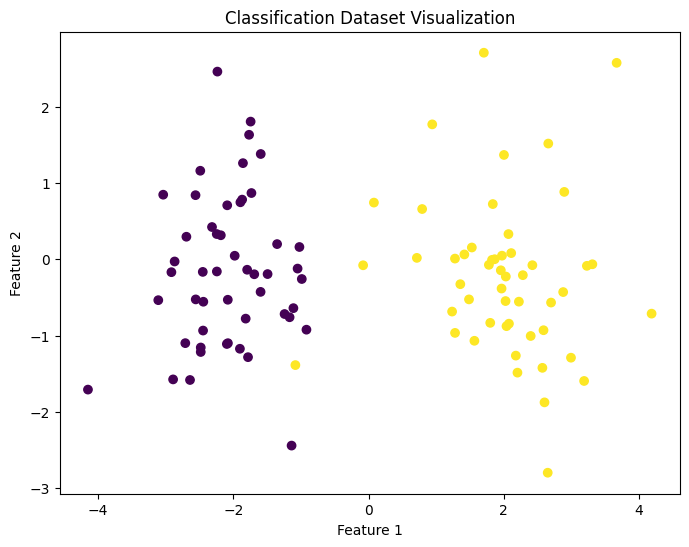

In [42]:
# Synthetic Dataset
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    class_sep = 2,
    random_state= 50
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y)

plt.title("Classification Dataset Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [43]:
X_temp = np.hstack((np.ones((X.shape[0], 1)), X))
epochs = 1000
lr = 0.01
# random initialization of w
w = np.random.randn(X_temp.shape[1])
weights_history = []
n = X_temp.shape[0]
for _ in range(epochs):
    # random point selection
    i = np.random.randint(0, X_temp.shape[0])
    
    # calculating y pred (step function)
    z = np.dot(X_temp[i], w)
    y_pred = 1 if z >= 0 else 0
    
    # updating the weights (perceptron update rule)
    w = w + lr * (y[i] - y_pred) * X_temp[i]

    weights_history.append(w.copy())

### Now the idea is to plot a line that will let us visualize  the decision boundary 

$w_{0}x_{0}+w_{1}x_{1}+w_{2}x_{2} =0$ is the current line 


This gives "$x_{1} = -\frac{w_{0}}{w_{1}} -\frac{x_{2}}{w_{1}}x_{2}$" which we would want to plot

Note: $x_{0} =1$

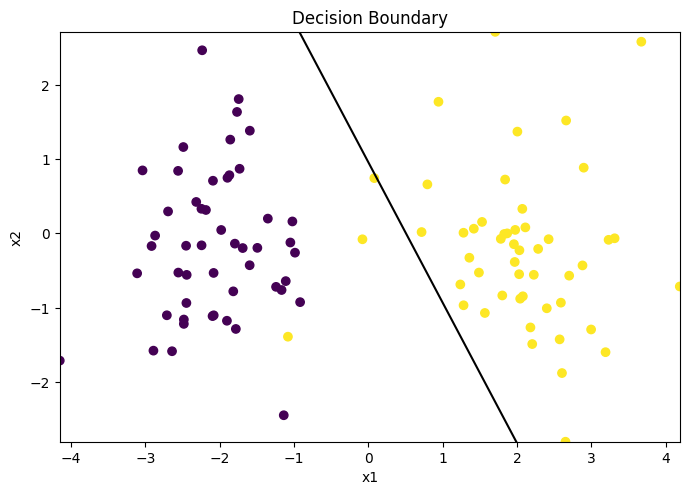

In [44]:
# extract weights
w0, w1, w2 = w

# create x1 values
x1_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)

# compute corresponding x2 values
x2_vals = -(w0 + w1 * x1_vals) / w2

# get consistent limits
x_min, x_max = X[:,0].min(), X[:,0].max()
y_min, y_max = X[:,1].min(), X[:,1].max()

plt.figure(figsize=(8, 6))

# plot data
plt.scatter(X[:,0], X[:,1], c=y)

# plot decision boundary
plt.plot(x1_vals, x2_vals, color='black')

# enforce same scales
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal', adjustable='box')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundary")
plt.show()

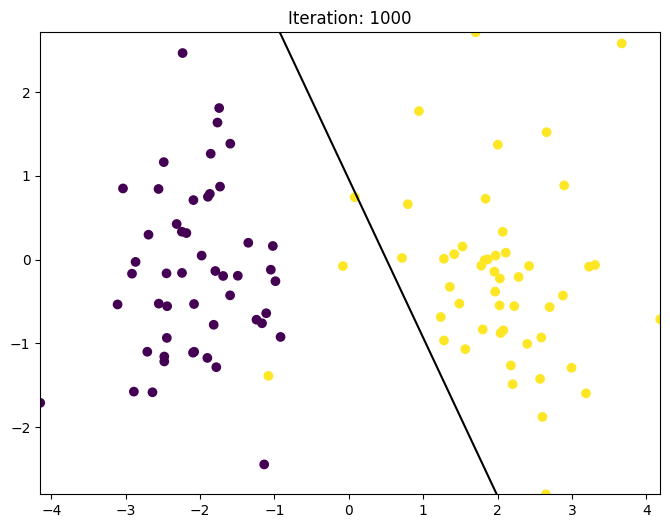

In [48]:
from IPython.display import clear_output
import time

for i, w in enumerate(weights_history):
    clear_output(wait=True)
    
    plt.figure(figsize=(8,6))
    plt.scatter(X[:,0], X[:,1], c=y)
    
    w0, w1, w2 = w
    
    if w2 != 0:
        x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
        y_vals = -(w0 + w1 * x_vals) / w2
        plt.plot(x_vals, y_vals, 'k-')
    
    plt.title(f"Iteration: {i+1}")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    
    plt.show()
